# 모델 선택 비교 (Model Selection with Optuna)

양산 DES 속도 예측을 위해 여러 회귀 모델을 Optuna로 하이퍼파라미터 튜닝하고 성능을 비교합니다.

**비교 모델:**
| 분류 | 모델 |
|---|---|
| 트리 부스팅 | LightGBM, GradientBoosting (GBM) |
| 앙상블 | RandomForest |
| 커널/선형 | SVR, Ridge, ElasticNet |
| 딥러닝 | MLP (MLPRegressor) |

**파이프라인 순서:**
1. 데이터 로드 및 전처리 (modeling.ipynb와 동일)
2. 각 모델별 Optuna 하이퍼파라미터 튜닝 (n_trials=50, Val RMSE 최소화)
3. 최적 파라미터로 Train+Val 재학습 후 Test 평가
4. R², RMSE, MAE 비교 및 시각화

## 0. 환경 설정

In [1]:
!pip install lightgbm optuna scikit-learn pandas numpy matplotlib seaborn joblib

## 1. 데이터 로드 및 전처리

modeling.ipynb와 동일한 전처리 파이프라인을 사용합니다.

- 사용 피처: 공정 수치 데이터 + 설비/재작업 범주형 변수
- 분리: Train(60%) / Val(20%) / Test(20%) — random_state=42

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import joblib
import warnings
warnings.filterwarnings('ignore')


def load_and_preprocess_data(csv_path='../data/Train_0319.csv'):
    raw_df = pd.read_csv(csv_path, encoding='cp949')

    df = raw_df[[
        'DRY FILM 정보', '선폭 OFFSET', '양산DES 속도',
        '거래처', '제품군', '공법구분', 'LAYER', '도금구분', '노광 설비정보',
        'DES 설비정보', '정면 설비정보', 'Cu 표면두께 Max_Val', 'Cu 표면두께 AVG_VAL',
        'Cu 표면두께 Min_Val', 'Cu 표면두께 Std_Val', 'Cu 표면두께 Median_Val',
        '재작업사유', '분석치_Etch factor', '분석치_Etching(염화동) - Cu',
        '분석치_Etching(염화동) - HCl', '분석치_Etching(염화동) - 비중',
        '분석치_Etching(염화동) - 온도', '분석치_Etching-첨가제(HB-120EF)',
        '분석치_Etching량', '분석치_Soft Etch - Cu', '분석치_Soft Etch - H2SO4',
        '분석치_Soft Etch - SPS', '분석치_박리액 - 농도', '분석치_수세수 - pH',
        '분석치_현상액 - pH', '분석치_현상액 - 농도'
    ]].copy()

    new_cols = [
        'df_type', 'width_offset', 'mass_des_speed',
        'customer', 'product_family', 'process_type', 'layer_count',
        'plating_type', 'expo_eq_id', 'des_eq_id', 'brush_eq_id', 'cu_thick_max',
        'cu_thick_avg', 'cu_thick_min', 'cu_thick_std', 'cu_thick_median',
        'rework_history', 'etch_factor', 'meas_etch_cu', 'meas_etch_hcl',
        'meas_etch_sg', 'meas_etch_temp', 'meas_etch_additive', 'meas_etch_amount',
        'meas_softetch_cu', 'meas_softetch_h2so4', 'meas_softetch_sps',
        'meas_strip_conc', 'meas_rinse_ph', 'meas_dev_ph', 'meas_dev_conc'
    ]
    df.columns = new_cols

    drop_cols = ['df_type', 'customer', 'product_family', 'process_type',
                 'layer_count', 'plating_type', 'width_offset']
    df = df.drop(columns=drop_cols)

    y = df['mass_des_speed'].round(2)
    x = df.drop(columns=['mass_des_speed'])

    categorical_features = ['rework_history', 'expo_eq_id', 'des_eq_id', 'brush_eq_id']
    numeric_features = [col for col in x.columns if col not in categorical_features]

    x[numeric_features] = x[numeric_features].fillna(x[numeric_features].median())
    for cat_col in categorical_features:
        x[cat_col] = x[cat_col].fillna('Unknown').astype(str)

    x_temp, x_test_set, y_temp, y_test_set = train_test_split(x, y, test_size=0.2, random_state=42)
    x_train_set, x_val_set, y_train_set, y_val_set = train_test_split(x_temp, y_temp, test_size=0.25, random_state=42)

    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

    x_train_transformed = preprocessor.fit_transform(x_train_set)
    x_val_transformed   = preprocessor.transform(x_val_set)
    x_test_transformed  = preprocessor.transform(x_test_set)

    cat_encoder = preprocessor.named_transformers_['cat']
    encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_features)
    final_columns = numeric_features + list(encoded_cat_cols)

    X_train = pd.DataFrame(x_train_transformed, columns=final_columns, index=x_train_set.index)
    X_val   = pd.DataFrame(x_val_transformed,   columns=final_columns, index=x_val_set.index)
    X_test  = pd.DataFrame(x_test_transformed,  columns=final_columns, index=x_test_set.index)

    joblib.dump(preprocessor, 'preprocessor.pkl')

    return X_train, X_val, X_test, y_train_set, y_val_set, y_test_set


X_train, X_val, X_test, y_train, y_val, y_test = load_and_preprocess_data('../data/Train_0319.csv')
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (4899, 45), Val: (1633, 45), Test: (1634, 45)


## 2. 라이브러리 및 모델 임포트

- **Optuna**: 하이퍼파라미터 튜닝 (TPE 샘플러, n_trials=50)
- **MLPRegressor**: 딥러닝 대표 모델 (다층 퍼셉트론, sklearn 내장)
  - 최대 4개 은닉층, 노드 수 32~512, relu/tanh 활성화 함수 탐색
  - 추가 가능한 딥러닝 모델: TabNet(`pip install pytorch-tabnet`), PyTorch MLP

In [3]:
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import seaborn as sns

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 50

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("임포트 완료")

임포트 완료


## 3. Optuna 하이퍼파라미터 튜닝

각 모델별 objective 함수를 정의합니다. Val RMSE를 최소화하는 방향으로 탐색합니다.

| 모델 | 주요 탐색 파라미터 |
|---|---|
| LightGBM | n_estimators, learning_rate, max_depth, num_leaves, subsample, colsample_bytree |
| RandomForest | n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features |
| GBM | n_estimators, learning_rate, max_depth, subsample, min_samples_split |
| SVR | C, epsilon, kernel, gamma |
| Ridge | alpha |
| ElasticNet | alpha, l1_ratio |
| MLP | hidden_layer_sizes, activation, alpha, learning_rate_init |

In [4]:
def objective_lgbm(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 15),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 200),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42, 'verbose': -1
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    return rmse(y_val, model.predict(X_val))


def objective_rf(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 30),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.8]),
        'random_state': 42, 'n_jobs': -1
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    return rmse(y_val, model.predict(X_val))


def objective_gbm(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 2, 10),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42
    }
    model = GradientBoostingRegressor(**params)
    model.fit(X_train, y_train)
    return rmse(y_val, model.predict(X_val))


def objective_svr(trial):
    kernel = trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly'])
    params = {
        'C':       trial.suggest_float('C', 0.1, 100.0, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.01, 1.0, log=True),
        'kernel':  kernel,
    }
    if kernel == 'rbf':
        params['gamma'] = trial.suggest_float('gamma', 1e-4, 1.0, log=True)
    elif kernel == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 4)
    model = SVR(**params)
    model.fit(X_train, y_train)
    return rmse(y_val, model.predict(X_val))


def objective_ridge(trial):
    params = {'alpha': trial.suggest_float('alpha', 1e-3, 100.0, log=True)}
    model = Ridge(**params)
    model.fit(X_train, y_train)
    return rmse(y_val, model.predict(X_val))


def objective_elasticnet(trial):
    params = {
        'alpha':    trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
        'max_iter': 5000
    }
    model = ElasticNet(**params)
    model.fit(X_train, y_train)
    return rmse(y_val, model.predict(X_val))


def objective_mlp(trial):
    n_layers = trial.suggest_int('n_layers', 1, 4)
    units = [trial.suggest_int(f'n_units_l{i}', 32, 512) for i in range(n_layers)]
    params = {
        'hidden_layer_sizes':  tuple(units),
        'activation':          trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha':               trial.suggest_float('alpha', 1e-5, 0.1, log=True),
        'learning_rate_init':  trial.suggest_float('learning_rate_init', 1e-4, 0.01, log=True),
        'batch_size':          trial.suggest_categorical('batch_size', [32, 64, 128]),
        'max_iter': 300, 'random_state': 42, 'early_stopping': True,
        'validation_fraction': 0.1, 'n_iter_no_change': 20
    }
    model = MLPRegressor(**params)
    model.fit(X_train, y_train)
    return rmse(y_val, model.predict(X_val))


print("Objective 함수 정의 완료")

Objective 함수 정의 완료


In [5]:
models_objectives = {
    'LightGBM':    objective_lgbm,
    'RandomForest':objective_rf,
    'GBM':         objective_gbm,
    'SVR':         objective_svr,
    'Ridge':       objective_ridge,
    'ElasticNet':  objective_elasticnet,
    'MLP':         objective_mlp,
}

best_params_all = {}
best_val_rmse   = {}

for model_name, objective in models_objectives.items():
    print(f"[{model_name}] Optuna 튜닝 중... (n_trials={N_TRIALS})")
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    best_params_all[model_name] = study.best_params
    best_val_rmse[model_name]   = study.best_value
    print(f"  Val RMSE: {study.best_value:.4f} | Best Params: {study.best_params}\n")

print("=" * 50)
print("전체 모델 튜닝 완료")

[LightGBM] Optuna 튜닝 중... (n_trials=50)
  Val RMSE: 0.1084 | Best Params: {'n_estimators': 363, 'learning_rate': 0.04349648730668662, 'max_depth': 13, 'num_leaves': 102, 'subsample': 0.8743349092844837, 'colsample_bytree': 0.5991696665546214, 'reg_alpha': 0.04500682915004937, 'reg_lambda': 0.33332919813449957}

[RandomForest] Optuna 튜닝 중... (n_trials=50)
  Val RMSE: 0.1128 | Best Params: {'n_estimators': 347, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.8}

[GBM] Optuna 튜닝 중... (n_trials=50)
  Val RMSE: 0.1056 | Best Params: {'n_estimators': 482, 'learning_rate': 0.03961645790679854, 'max_depth': 9, 'subsample': 0.8856534120271543, 'min_samples_split': 6, 'min_samples_leaf': 4}

[SVR] Optuna 튜닝 중... (n_trials=50)
  Val RMSE: 0.1357 | Best Params: {'kernel': 'rbf', 'C': 6.499087108141039, 'epsilon': 0.10634351275715818, 'gamma': 0.056300453025014435}

[Ridge] Optuna 튜닝 중... (n_trials=50)
  Val RMSE: 0.1860 | Best Params: {'alpha': 1.1668127070008012}

## 4. 최종 학습 및 Test 평가

최적 파라미터로 Train + Val 합산 후 재학습, Test 셋으로 최종 성능을 평가합니다.

In [6]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])


def build_model(model_name, params):
    p = {k: v for k, v in params.items()}

    if model_name == 'LightGBM':
        return LGBMRegressor(**p, random_state=42, verbose=-1)

    elif model_name == 'RandomForest':
        return RandomForestRegressor(**p, random_state=42, n_jobs=-1)

    elif model_name == 'GBM':
        return GradientBoostingRegressor(**p, random_state=42)

    elif model_name == 'SVR':
        return SVR(**p)

    elif model_name == 'Ridge':
        return Ridge(**p)

    elif model_name == 'ElasticNet':
        p.setdefault('max_iter', 5000)
        return ElasticNet(**p)

    elif model_name == 'MLP':
        n_layers = p.pop('n_layers')
        units = tuple(p.pop(f'n_units_l{i}') for i in range(n_layers))
        # 최종 학습 시 early_stopping 비활성화 (Train+Val 전체 사용)
        p.pop('early_stopping', None)
        p.pop('validation_fraction', None)
        p.pop('n_iter_no_change', None)
        return MLPRegressor(
            hidden_layer_sizes=units,
            max_iter=500,
            early_stopping=False,
            random_state=42,
            **p
        )


results = []
trained_models = {}

print(f"{'Model':<15} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print("-" * 45)

for model_name, params in best_params_all.items():
    model = build_model(model_name, params.copy())
    model.fit(X_train_full, y_train_full)
    pred = model.predict(X_test)

    r2  = r2_score(y_test, pred)
    rms = rmse(y_test, pred)
    mae = mean_absolute_error(y_test, pred)

    results.append({'Model': model_name, 'R²': r2, 'RMSE': rms, 'MAE': mae})
    trained_models[model_name] = model
    print(f"{model_name:<15} {r2:>8.4f} {rms:>8.4f} {mae:>8.4f}")

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
results_df.index += 1

Model                 R²     RMSE      MAE
---------------------------------------------
LightGBM          0.9324   0.1117   0.0599
RandomForest      0.9315   0.1125   0.0560
GBM               0.9376   0.1073   0.0553
SVR               0.9026   0.1341   0.0930
Ridge             0.8193   0.1826   0.1287
ElasticNet        0.8191   0.1827   0.1292
MLP               0.8882   0.1436   0.0950


## 5. 성능 비교 (R², RMSE, MAE)

In [7]:
print("=" * 55)
print(" 최종 모델 성능 비교 (Test Set, R² 내림차순)")
print("=" * 55)
display(results_df.style
    .background_gradient(subset=['R²'], cmap='Greens')
    .background_gradient(subset=['RMSE', 'MAE'], cmap='Reds_r')
    .format({'R²': '{:.4f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}'})
)

best_model_name = results_df.iloc[0]['Model']
print(f"\n최고 성능 모델: {best_model_name} (R²={results_df.iloc[0]['R²']:.4f})")

 최종 모델 성능 비교 (Test Set, R² 내림차순)


,Model,R²,RMSE,MAE
1,GBM,0.9376,0.1073,0.0553
2,LightGBM,0.9324,0.1117,0.0599
3,RandomForest,0.9315,0.1125,0.0560
4,SVR,0.9026,0.1341,0.0930
5,MLP,0.8882,0.1436,0.0950
6,Ridge,0.8193,0.1826,0.1287
7,ElasticNet,0.8191,0.1827,0.1292



최고 성능 모델: GBM (R²=0.9376)


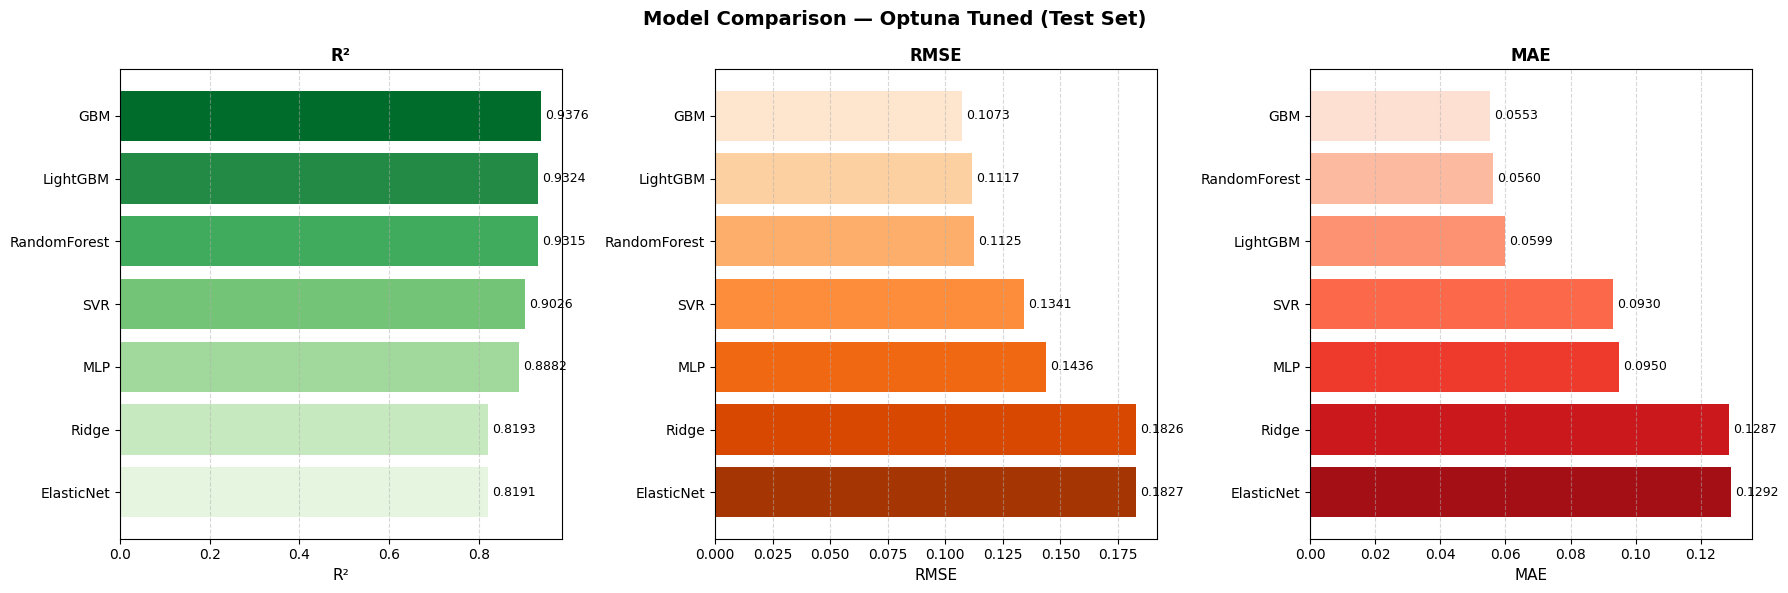

model_comparison.png 저장 완료


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison — Optuna Tuned (Test Set)', fontsize=14, fontweight='bold')

metrics = [
    ('R²',   'Greens',  True),
    ('RMSE', 'Oranges', False),
    ('MAE',  'Reds',    False),
]

for ax, (metric, cmap, ascending_color) in zip(axes, metrics):
    sorted_df = results_df.sort_values(metric, ascending=(not ascending_color))
    colors = sns.color_palette(cmap, len(sorted_df))
    if ascending_color:
        colors = colors[::-1]

    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("model_comparison.png 저장 완료")

## 6. 예측값 vs 실제값 산점도 (전 모델)

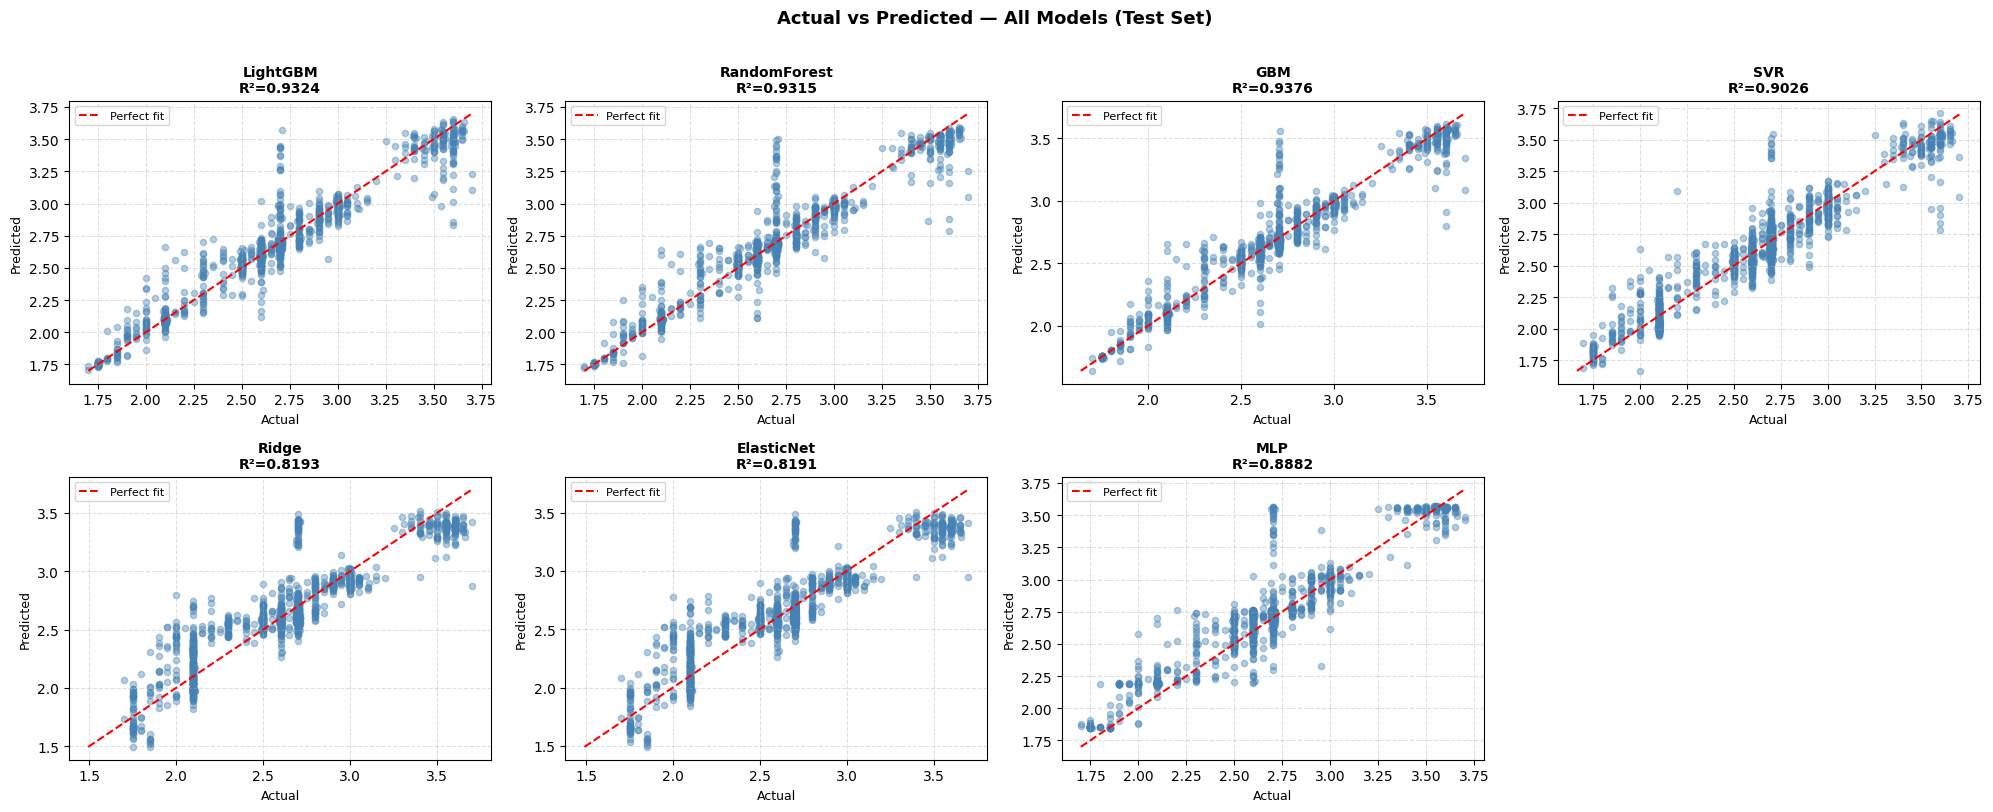

actual_vs_predicted_all.png 저장 완료


In [9]:
n_models = len(trained_models)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, (model_name, model) in enumerate(trained_models.items()):
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    ax = axes[i]
    ax.scatter(y_test, pred, alpha=0.4, s=20, color='steelblue')
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual', fontsize=9)
    ax.set_ylabel('Predicted', fontsize=9)
    ax.set_title(f'{model_name}\nR²={r2:.4f}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Actual vs Predicted — All Models (Test Set)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('actual_vs_predicted_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("actual_vs_predicted_all.png 저장 완료")

## 7. 최적 파라미터 요약

In [10]:
print("=" * 55)
print(" Optuna 최적 하이퍼파라미터 요약")
print("=" * 55)
for model_name, params in best_params_all.items():
    r2_val  = results_df[results_df['Model'] == model_name]['R²'].values[0]
    val_rms = best_val_rmse[model_name]
    print(f"\n[{model_name}]  Val RMSE={val_rms:.4f}  Test R²={r2_val:.4f}")
    for k, v in params.items():
        print(f"  {k}: {v}")

 Optuna 최적 하이퍼파라미터 요약

[LightGBM]  Val RMSE=0.1084  Test R²=0.9324
  n_estimators: 363
  learning_rate: 0.04349648730668662
  max_depth: 13
  num_leaves: 102
  subsample: 0.8743349092844837
  colsample_bytree: 0.5991696665546214
  reg_alpha: 0.04500682915004937
  reg_lambda: 0.33332919813449957

[RandomForest]  Val RMSE=0.1128  Test R²=0.9315
  n_estimators: 347
  max_depth: 19
  min_samples_split: 4
  min_samples_leaf: 1
  max_features: 0.8

[GBM]  Val RMSE=0.1056  Test R²=0.9376
  n_estimators: 482
  learning_rate: 0.03961645790679854
  max_depth: 9
  subsample: 0.8856534120271543
  min_samples_split: 6
  min_samples_leaf: 4

[SVR]  Val RMSE=0.1357  Test R²=0.9026
  kernel: rbf
  C: 6.499087108141039
  epsilon: 0.10634351275715818
  gamma: 0.056300453025014435

[Ridge]  Val RMSE=0.1860  Test R²=0.8193
  alpha: 1.1668127070008012

[ElasticNet]  Val RMSE=0.1862  Test R²=0.8191
  alpha: 0.0010112665192442683
  l1_ratio: 0.06647993222592846

[MLP]  Val RMSE=0.1165  Test R²=0.8882
  n_lay